In [1]:
import pandas as pd
import utils as uti
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


In [4]:
models

{'xgb woe': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8261937960243363, device=None,
               early_stopping_rounds=None, enable_categorical=True,
               eval_metric='auc', feature_types=None, feature_weights=None,
               gamma=2.0803290572724848e-05, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.10162406008901824, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=3.582357860303052, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=-1, num_parallel_tree=None, ...),
 'logi': <statsmodels.discrete.discrete_model.BinaryResultsWrapper at 0x71189d359a90>,
 'xgb raw': XGBClassifier(base_score=None, b

# variable selection

In [5]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,auc,corr,corr ind
0,checking_account_status_woe,0.700714,0.228923,False
1,credit_history_woe,0.641429,0.414942,True
2,purpose_woe,0.609829,0.137224,False
3,savings_account_bonds_woe,0.607543,0.228923,False
4,duration_months_woe,0.602352,0.181447,False


In [6]:
log_vars = walds[walds['corr ind'] == False]['var'].tolist()
# log_vars = walds['var'].tolist()
log_vars

['checking_account_status_woe',
 'purpose_woe',
 'savings_account_bonds_woe',
 'duration_months_woe',
 'employment_since_woe',
 'property_woe',
 'housing_woe',
 'other_installment_plans_woe',
 'credit_amount_woe',
 'installment_rate_percent_woe',
 'telephone_woe',
 'residence_since_woe']

In [7]:
X = df[log_vars]
y = df.bad

In [8]:
selected_features, selection_history = uti.forward_select_auc(X, y)

print(f'Selected Features: {selected_features}')
print(selection_history)

Added checking_account_status_woe    CV AUC = 0.7012
Added duration_months_woe            CV AUC = 0.7398
Added purpose_woe                    CV AUC = 0.7602
Added savings_account_bonds_woe      CV AUC = 0.7747
Added other_installment_plans_woe    CV AUC = 0.7840
Added credit_amount_woe              CV AUC = 0.7909
Added employment_since_woe           CV AUC = 0.7950
Added installment_rate_percent_woe   CV AUC = 0.8006
Added property_woe                   CV AUC = 0.8025
Selected Features: ['checking_account_status_woe', 'duration_months_woe', 'purpose_woe', 'savings_account_bonds_woe', 'other_installment_plans_woe', 'credit_amount_woe', 'employment_since_woe', 'installment_rate_percent_woe', 'property_woe']
                          added  \
0   checking_account_status_woe   
1           duration_months_woe   
2                   purpose_woe   
3     savings_account_bonds_woe   
4   other_installment_plans_woe   
5             credit_amount_woe   
6          employment_since_woe   
7

In [9]:
selected_features

['checking_account_status_woe',
 'duration_months_woe',
 'purpose_woe',
 'savings_account_bonds_woe',
 'other_installment_plans_woe',
 'credit_amount_woe',
 'employment_since_woe',
 'installment_rate_percent_woe',
 'property_woe']

In [10]:
df.groupby('bad').size()

bad
0    350
1    150
dtype: int64

In [11]:
df.groupby('bad').size()[1]

np.int64(150)

# pair plot of selected

## raw numeric variables

In [12]:
raw_list = [selected_features.removesuffix('_woe') for selected_features in selected_features]
raw_list

['checking_account_status',
 'duration_months',
 'purpose',
 'savings_account_bonds',
 'other_installment_plans',
 'credit_amount',
 'employment_since',
 'installment_rate_percent',
 'property']

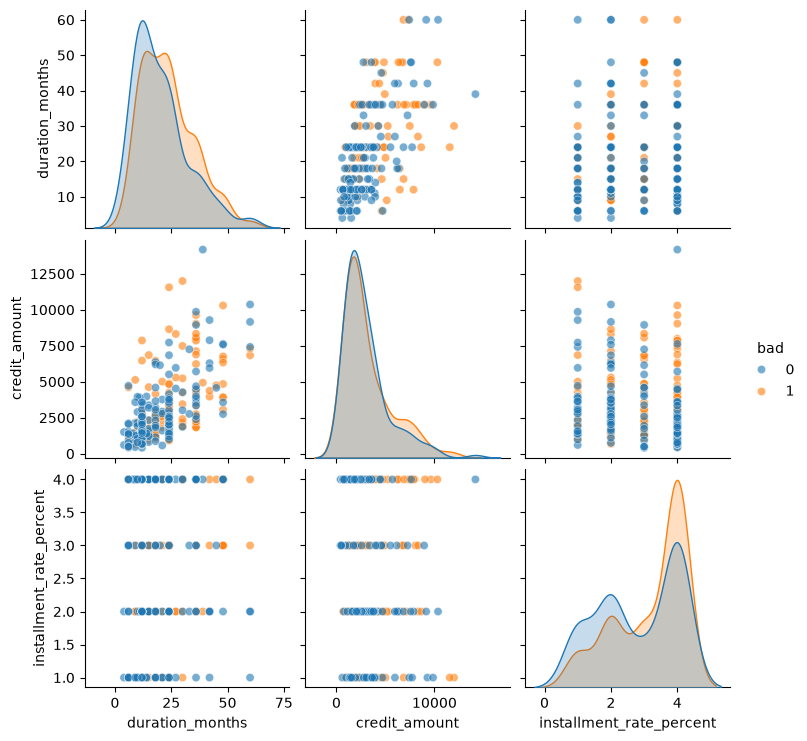

In [13]:
import seaborn as sns

combined = pd.concat(
    [df[raw_list + ['bad']][df.bad == 1],
     df[raw_list + ['bad']][df.bad == 0].sample(n=df.groupby('bad').size()[1], random_state=42).reset_index(drop=True)], 
    axis=0, 
    ignore_index=True
)


sns.pairplot(
    combined,
    hue="bad",
    height=2.5,
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

plt.show()

## weight of evidence

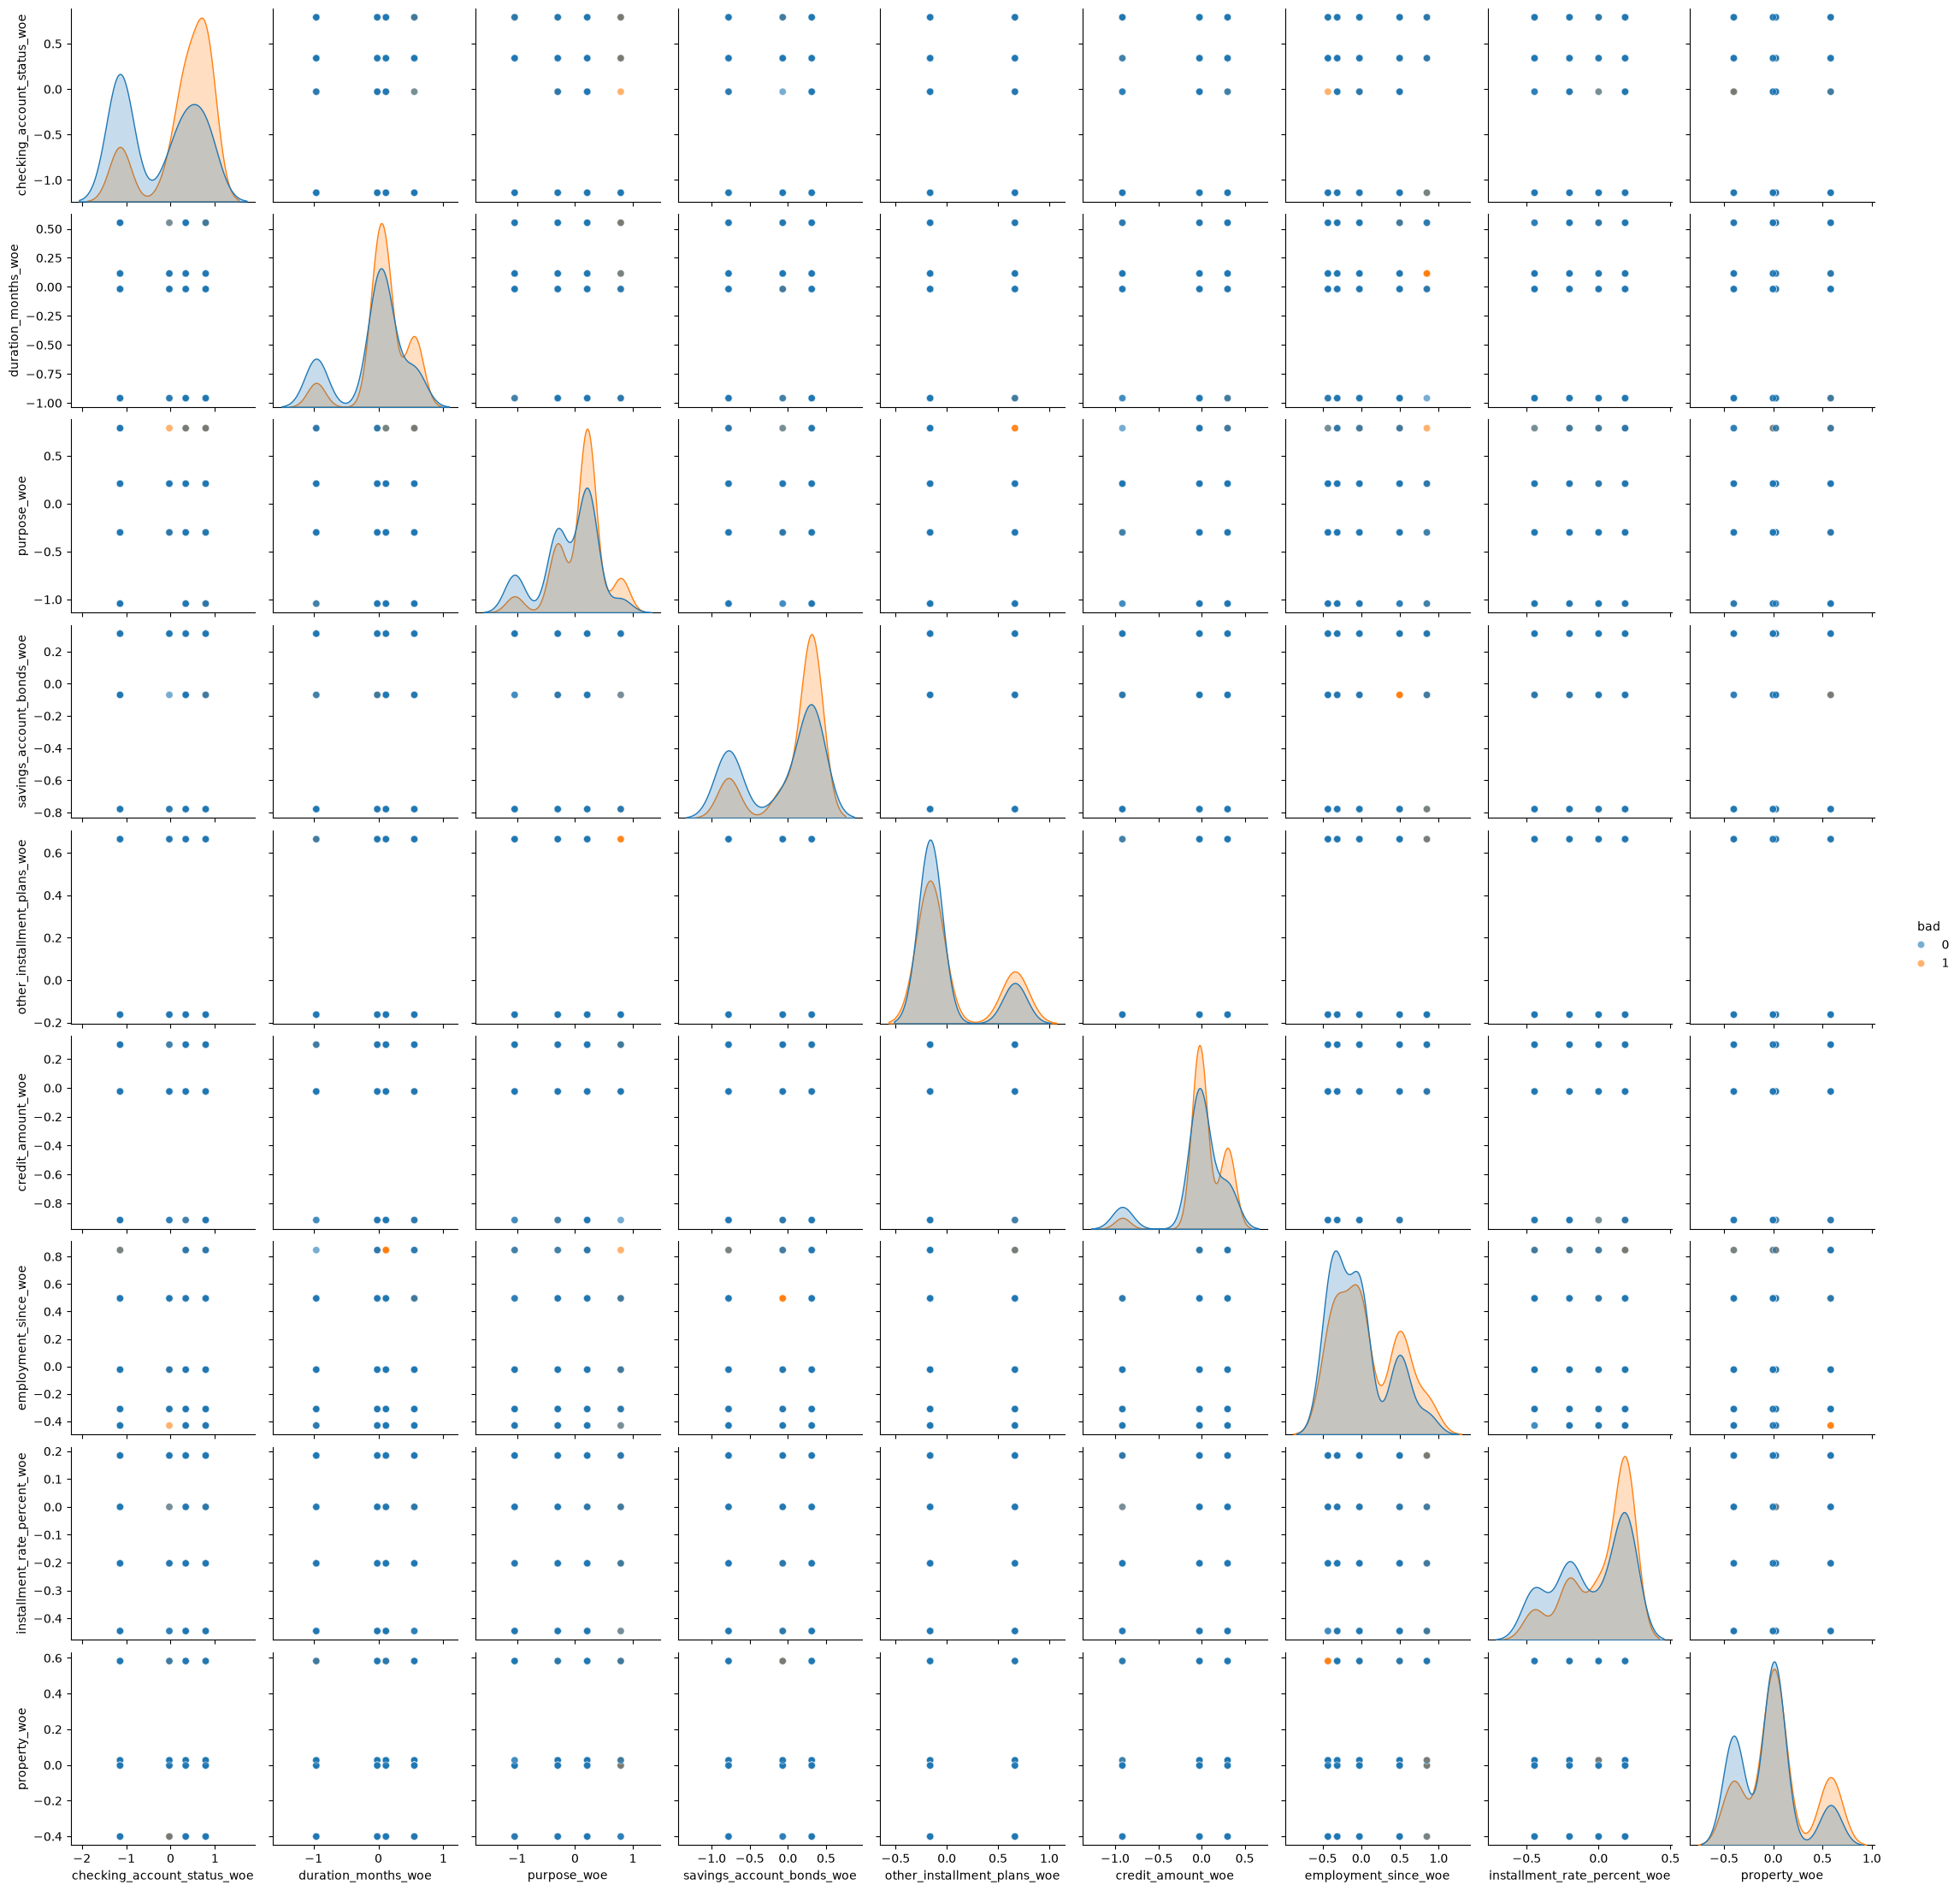

In [14]:
import seaborn as sns

combined = pd.concat(
    [df[selected_features + ['bad']][df.bad == 1],
     df[selected_features + ['bad']][df.bad == 0].sample(n=df.groupby('bad').size()[1], random_state=42).reset_index(drop=True)], 
    axis=0, 
    ignore_index=True
)


sns.pairplot(
    combined,
    hue="bad",
    height=2.5,
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

plt.show()

# estimate final

In [15]:
import statsmodels.api as sm

X_selected = sm.add_constant(
    X[selected_features],
    has_constant="add"
)

final_model = sm.Logit(y, X_selected).fit()

print(final_model.summary())

Optimization terminated successfully.
         Current function value: 0.469653
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    bad   No. Observations:                  500
Model:                          Logit   Df Residuals:                      490
Method:                           MLE   Df Model:                            9
Date:                Sat, 12 Sep 2026   Pseudo R-squ.:                  0.2312
Time:                        04:50:21   Log-Likelihood:                -234.83
converged:                       True   LL-Null:                       -305.43
Covariance Type:            nonrobust   LLR p-value:                 5.800e-26
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -0.8508      0.117     -7.258      0.000

# marginal effects

In [16]:
mfx = final_model.get_margeff(at="overall")

In [17]:
mfx = final_model.get_margeff(
    at="overall",
    dummy=True,       # appropriate handling for binary predictors
    count=True        # appropriate handling for count variables
)

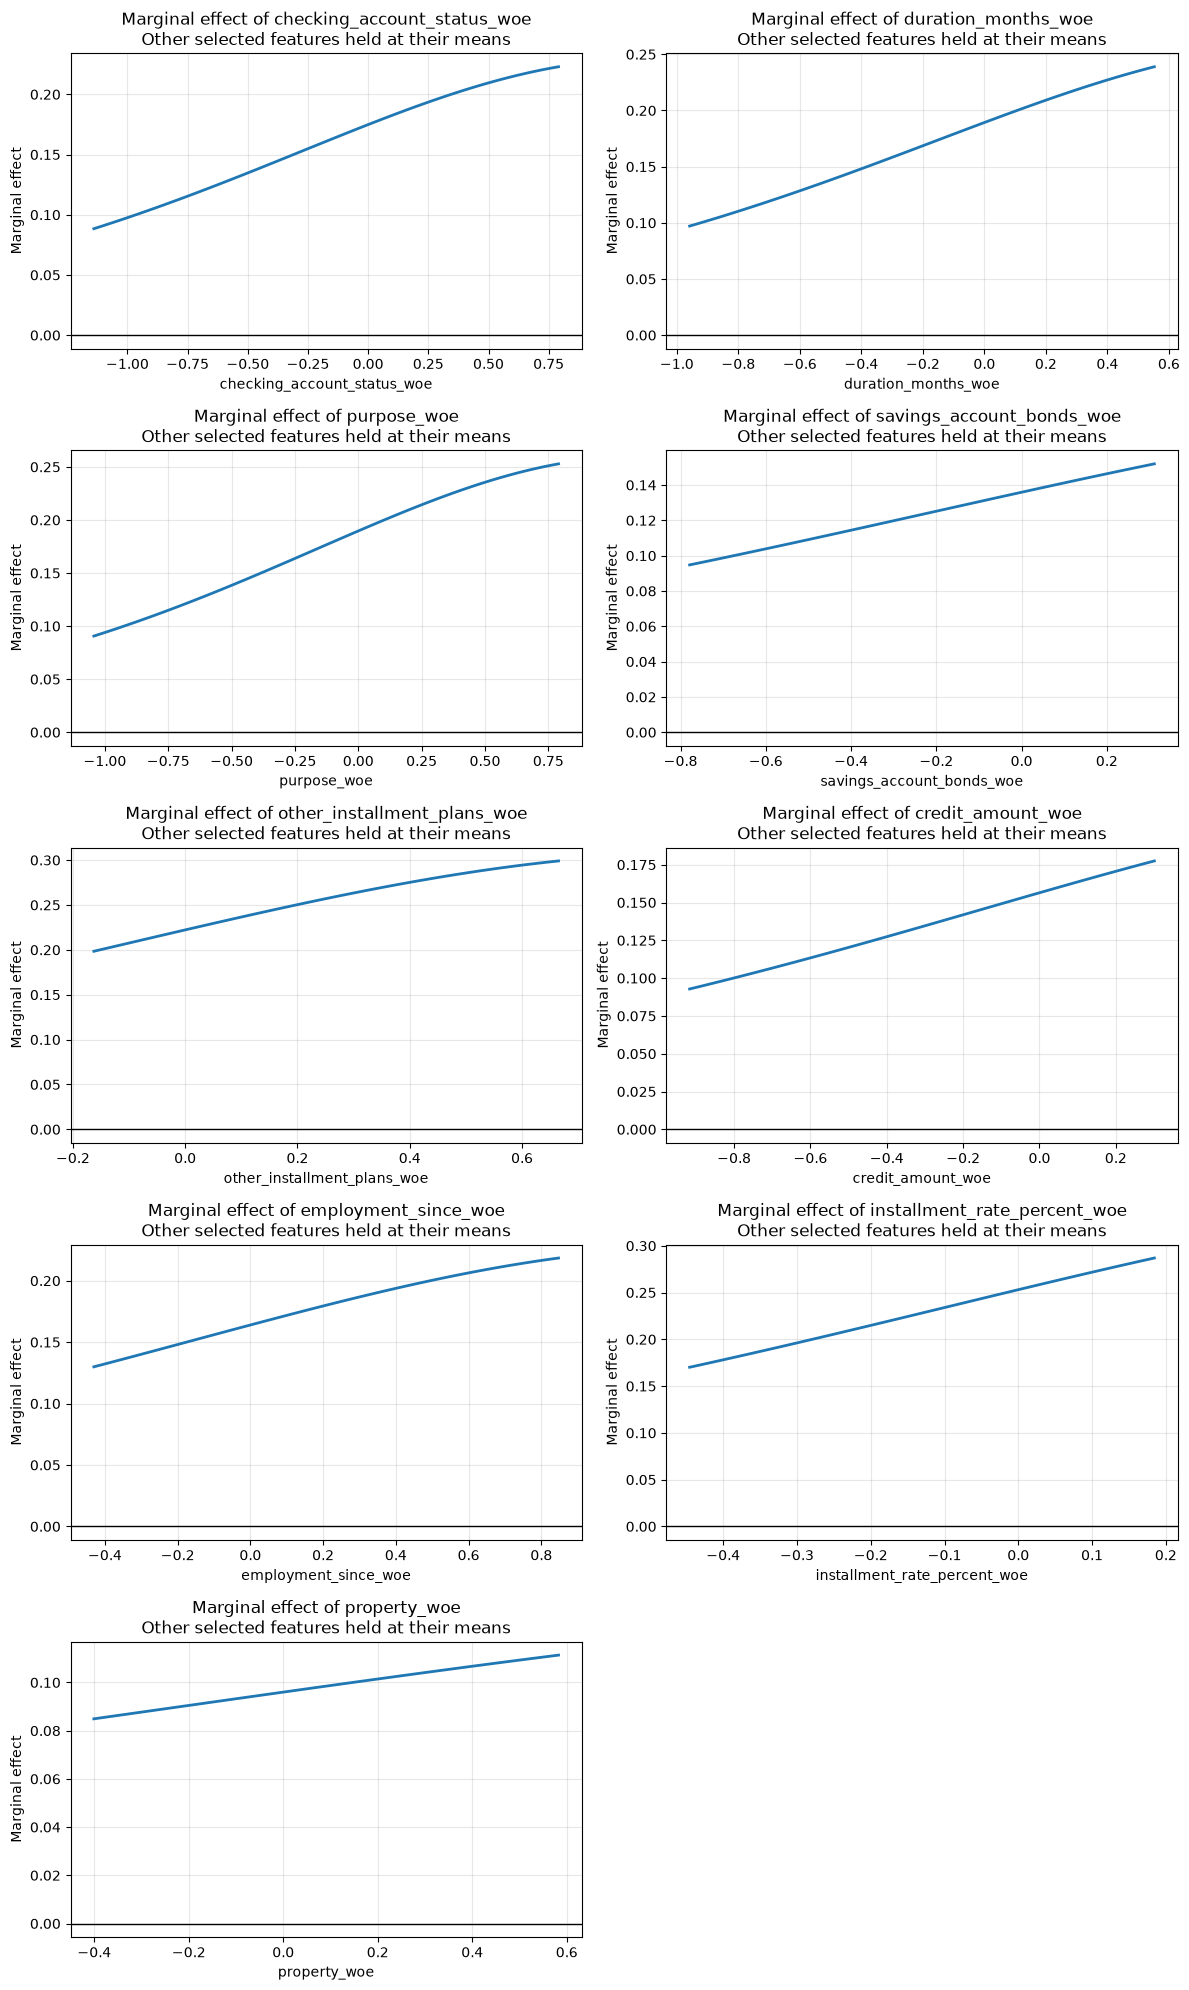

In [18]:
import math
import matplotlib.pyplot as plt

n_features = len(selected_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows),
    squeeze=False
)

axes = axes.flatten()

for i, feature in enumerate(selected_features):
    uti.plot_logit_marginal_effect(
        model=final_model,
        data=df,
        variable=feature,
        selected_features=selected_features,
        ax=axes[i]
    )

# Hide unused axes if the number of features is not even
for ax in axes[n_features:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# save model

In [19]:
models['logi'] = final_model

In [20]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)